In [5]:
import numpy as np
import warnings
from joblib import Parallel, delayed
import sys
sys.path.append('../models')
from traditional_npz import npz_nl, rk4, run_rk4_for_initial_conditions
sys.path.append('../utils')
from additional_files import sample_npz_uniformN_dirichletPZ, calculate_fixed_points


In [6]:

# def npz_nl(x, t, Vm, ks, m, Rm, ivlev, gamma, q):
#     x = np.asarray(x)
#     dx = np.zeros(x.shape)

    
#     dx[1] = (((Vm * x[0]) / (ks + x[0])) * x[1]) - (m * x[1]) - (ivlev * x[1] * Rm * (1 - np.exp(-ivlev * x[1])) * x[2])
#     dx[2] = ((1 - gamma) * ivlev * x[1] * Rm * (1 - np.exp(-ivlev * x[1])) * x[2]) - (q * x[2])
#     dx[0] = -(((Vm * x[0]) / (ks + x[0])) * x[1]) + (m * x[1]) + (q * x[2]) + (gamma * ivlev * x[1] * Rm * (1 - np.exp(-ivlev * x[1])) * x[2])
    
#     return dx
    
# def rk4(f, x0, times, tfrc, frc, args):
#     """
#     Perform the model integration using the Runge-Kutta 4. This
#     allows for the function to be forced at given times, ft, by the forcing, f.
#     """
#     nt = len(times)
#     x = np.zeros((nt, len(x0)))
#     x[0, :] = x0
#     dt = np.zeros(nt)
#     dt[1:] = np.diff(times)
#     for n in range(1, nt):
#         k1 = f(x[n - 1, :], times[n], *args) * dt[n]
#         k2 = f(x[n - 1, :] + 0.5 * k1, times[n] + 0.5 * dt[n], *args) * dt[n]
#         k3 = f(x[n - 1, :] + 0.5 * k2, times[n] + 0.5 * dt[n], *args) * dt[n]
#         k4 = f(x[n - 1, :] + k3, times[n] + dt[n], *args) * dt[n]
#         x[n, :] = x[n - 1, :] + (k1 + 2 * k2 + 2 * k3 + k4) / 6

#         if tfrc is not None:
#             fl = np.where(np.logical_and(tfrc >= times[n] - 0.5 * dt[n],
#                                          tfrc < times[n] + 0.5 * dt[n]))[0]
#             x[n, :] += f[fl, :].sum(axis=0)

#     return x

# # RK4 for a single set of initial conditions
# def run_rk4_for_initial_conditions(N0, P0, Z0, t, phi):
#     # Define the initial conditions as a list
#     x0 = [N0, P0, Z0]
#     # Use the rk4 method to expand the system over time
#     xt = rk4(npz_nl, x0, t, None, 0, phi)
#     return xt


# def calculate_fixed_points(IC, Vm=2, ks=1, m=0.1, Rm=1.5, ivlev=1, gamma=0.3, q=0.2, mp=True):
#     """
#     Compute the fixed points for the NPZ system given an initial condition [N, P, Z].
#     """
#     N0, P0, Z0 = IC
#     Ntot = N0 + P0 + Z0

#     if mp:
#         def fpf(ppf):
#             return (ppf * (1. - np.exp(-ivlev * Ntot * ppf))) - \
#                 ((q / Vm) / ((Rm / Vm) * ivlev * Ntot * (1. - gamma)))

#         try:
#             # Pf_guess = np.min(fsolve(fpf, np.array([0.01, 0.99])))
#             Pf_guess = fsolve(fpf, 0.5)[0]  # cleaner and safer
#             if (Pf_guess < 0) or (not np.isclose(Pf_guess, 0.49, atol=0.01)):
#                 # Check signs before using brentq
#                 if np.sign(fpf(0.01)) == np.sign(fpf(0.99)):
#                     return np.array([np.nan, np.nan, np.nan])
#                 Pf = brentq(fpf, 0.01, 0.99)
#             else:
#                 Pf = Pf_guess
#         except Exception:
#             return np.array([np.nan, np.nan, np.nan])
#     else:
#         try:
#             inner_term = 1 - ((q / Vm) / ((Rm / Vm) * (1 - gamma)))
#             if inner_term <= 0:
#                 return np.array([np.nan, np.nan, np.nan])
#             Pf = -1.0 / (ivlev * Ntot) * np.log(inner_term)
#         except Exception:
#             return np.array([np.nan, np.nan, np.nan])

#     # Quadratic for Zf
#     a = -(q / Vm) / (1 - gamma)
#     b = ((q / Vm) / (1 - gamma)) * ((ks / Ntot) + 1 - Pf) + Pf - ((m / Vm) * Pf)
#     c = Pf * ((m / Vm) * ((ks / Ntot) + 1 - Pf) + Pf - 1)

#     discriminant = b ** 2 - 4 * a * c
#     if discriminant < 0:
#         return np.array([np.nan, np.nan, np.nan])

#     # Zf_candidates = [(-b + np.sqrt(discriminant)) / (2 * a),
#     #                  (-b - np.sqrt(discriminant)) / (2 * a)]
#     # Zf = np.min(Zf_candidates)

#     Zf_candidates = [z for z in [
#         (-b + np.sqrt(discriminant)) / (2 * a),
#         (-b - np.sqrt(discriminant)) / (2 * a)
#     ] if 0 < z < 1 - Pf]
    
#     if not Zf_candidates:
#         return np.array([np.nan, np.nan, np.nan])
    
#     Zf = Zf_candidates[0]  # Or choose max/min depending on expected steady state
    
#     Nf = 1 - Pf - Zf
#     Pf *= Ntot
#     Zf *= Ntot
#     Nf *= Ntot

#     return np.array([Nf, Pf, Zf])


In [7]:
# --- Example usage ---
np.random.seed(42)   # global seed for reproducibility
num_states = 20_000
npz_matrix = sample_npz_uniformN_dirichletPZ(n_samples=num_states)
print(npz_matrix)
print("Row sums:", npz_matrix.sum(axis=1))


[[0.77659725 1.15217661 0.17948748]
 [1.77509737 0.08250991 0.21101242]
 [1.10039781 0.1765768  0.36004747]
 ...
 [0.5161185  0.35751038 0.80129909]
 [0.9073011  0.68535297 0.53305896]
 [0.34377589 0.58253898 0.82384795]]
Row sums: [2.10826135 2.06861969 1.63702208 ... 1.67492796 2.12571303 1.75016283]


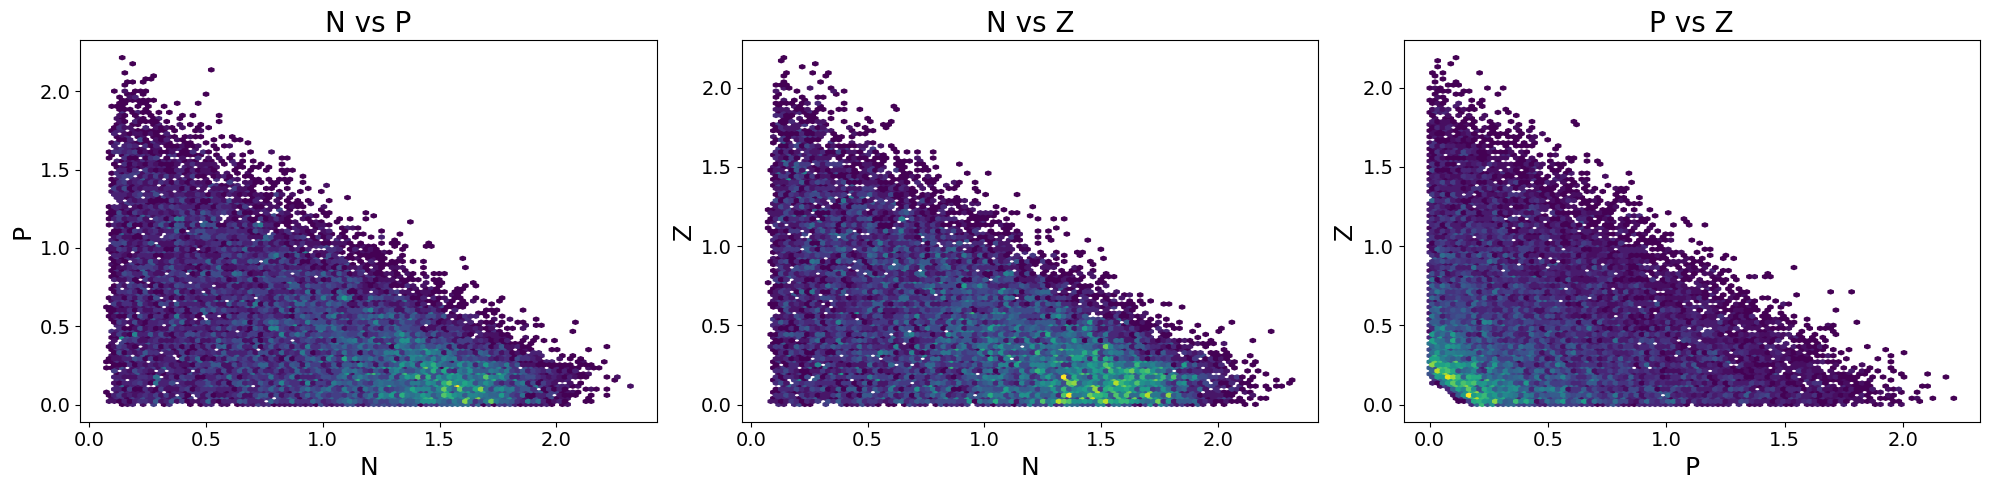

In [8]:
import matplotlib.pyplot as plt
N = npz_matrix[:,0]
P = npz_matrix[:,1]
Z = npz_matrix[:,2]

fig, axs = plt.subplots(1, 3, figsize=(20, 5))

font_title = 20
font_label = 18
font_tick = 14

# N vs P
axs[0].hexbin(N, P, gridsize=100, cmap='viridis', mincnt=1)
axs[0].set_xlabel("N", fontsize=font_label)
axs[0].set_ylabel("P", fontsize=font_label)
axs[0].set_title("N vs P", fontsize=font_title)
axs[0].tick_params(axis='both', labelsize=font_tick)

# N vs Z
axs[1].hexbin(N, Z, gridsize=100, cmap='viridis', mincnt=1)
axs[1].set_xlabel("N", fontsize=font_label)
axs[1].set_ylabel("Z", fontsize=font_label)
axs[1].set_title("N vs Z", fontsize=font_title)
axs[1].tick_params(axis='both', labelsize=font_tick)

# P vs Z
axs[2].hexbin(P, Z, gridsize=100, cmap='viridis', mincnt=1)
axs[2].set_xlabel("P", fontsize=font_label)
axs[2].set_ylabel("Z", fontsize=font_label)
axs[2].set_title("P vs Z", fontsize=font_title)
axs[2].tick_params(axis='both', labelsize=font_tick)

plt.tight_layout()
# plt.savefig("/Users/egank31/Documents/Documents - Otto/lab_meetings/figures/uniformN_dirPZ_initial_npz_hexbin_plots.png", dpi=300, bbox_inches='tight')
plt.show()


In [9]:
Vm     = 2.0
ks     = 1.0
m      = 0.1
gamma  = 0.3
Rm     = 1.5
ivlev  = 1.0
q      = 0.2
phi = (Vm, ks, m, Rm, ivlev, gamma, q)

tstart = 0 # Start time (day 0)
tend = 7 #total_days # End time (day 8)
minutes_per_step = 10 # Time step in minutes
minutes_per_hour = 60 # Constant time per hour
hours_per_day = 24 # Constant time per day
dt = minutes_per_step / (minutes_per_hour * hours_per_day)
steps = int((tend - tstart) / dt)
t = np.linspace(tstart, tend, steps + 1)
def evolve_single(IC, times, phi):
    return rk4(npz_nl, IC, times, None, None, phi)

training_ICs = npz_matrix.copy()
# Run parallel evolution for many ICs
results = Parallel(n_jobs=-1)(delayed(evolve_single)(IC, t, phi) for IC in training_ICs)


In [10]:
# After the Parallel call
traj = np.stack(results, axis=0)   # shape (nIC, nT, 3)

# Now you can safely do
Ntot_vals = traj.sum(axis=2)   # shape (nIC, nT)
Ntot_keys = np.round(Ntot_vals, 1)

# Define the Ntot values you want to test
Ntot_values = np.arange(Ntot_vals.min(), Ntot_vals.max(), 0.1)  # 1.8, 1.9, ..., 2.2

fixed_points = {}

for Ntot in Ntot_values:
    # just pick any IC that sums to Ntot, the function only cares about Ntot
    IC = np.array([Ntot*0.7, Ntot*0.2, Ntot*0.1])
    fp = calculate_fixed_points(IC)
    fixed_points[round(Ntot,1)] = fp
    print(f"Ntot={Ntot:.1f} → Fixed point: {fp}, Total={fp.sum():.3f}")


Ntot=1.2 → Fixed point: [0.22290158 0.49096383 0.45458781], Total=1.168
Ntot=1.3 → Fixed point: [0.25375121 0.49096383 0.52373818], Total=1.268
Ntot=1.4 → Fixed point: [0.28567886 0.49096383 0.59181053], Total=1.368
Ntot=1.5 → Fixed point: [0.31871433 0.49096383 0.65877506], Total=1.468
Ntot=1.6 → Fixed point: [0.35288658 0.49096383 0.72460281], Total=1.568
Ntot=1.7 → Fixed point: [0.38822355 0.49096383 0.78926584], Total=1.668
Ntot=1.8 → Fixed point: [0.42475195 0.49096383 0.85273744], Total=1.768
Ntot=1.9 → Fixed point: [0.46249703 0.49096383 0.91499236], Total=1.868
Ntot=2.0 → Fixed point: [0.5014824  0.49096383 0.97600699], Total=1.968
Ntot=2.1 → Fixed point: [0.5417298  0.49096383 1.03575959], Total=2.068
Ntot=2.2 → Fixed point: [0.5832589  0.49096383 1.09423049], Total=2.168
Ntot=2.3 → Fixed point: [0.62608711 0.49096383 1.15140228], Total=2.268
Ntot=2.4 → Fixed point: [0.67022944 0.49096383 1.20725995], Total=2.368
Ntot=2.5 → Fixed point: [0.7156983  0.49096383 1.26179109], Tota

In [11]:
# --- NEW: measure, but don’t filter ---
fraction_in_range = np.mean((Ntot_vals >= 1.8) & (Ntot_vals <= 2.2))
print(f"Fraction of states in [1.8, 2.2]: {fraction_in_range:.2%}")

fp_lookup = np.zeros_like(traj)
for key, fp in fixed_points.items():
    mask = (Ntot_keys == key)
    fp_lookup[mask] = fp

# Distances to fixed points
distances = np.linalg.norm(traj - fp_lookup, axis=2)  # shape (nIC, nT)

# Split into near / mid / far (for ALL states, not just in range)
# Exclude "super-near" points < 0.1
near_mask = (distances >= 0.1) & (distances < 1.0)
# mid_mask  = (distances >= 1.0)# & (distances < 2.0)
# far_mask  = distances >= 2.0
far_mask  = (distances >= 1.0)# & (distances < 2.0)

near_states = traj[near_mask]
# mid_states  = traj[mid_mask]
far_states  = traj[far_mask]

print("Near:", near_states.shape)
# print("Mid:", mid_states.shape)
print("Far:", far_states.shape)


Fraction of states in [1.8, 2.2]: 67.91%
Near: (12313407, 3)
Far: (2686793, 3)


In [ ]:
# n_total = 500_000

# # Adjust ratio of near:mid
# near_percentage = 0.3
# n_near = int(near_percentage * n_total)
# n_far  = int((1-near_percentage)*n_total)   # use all far
# # remaining = n_total - n_far

# # n_mid  = remaining - n_near
# # n_far  = remaining - n_near

# np.random.seed(42)
# near_subset = near_states[np.random.choice(len(near_states), n_near, replace=False)]
# # mid_subset  = mid_states[np.random.choice(len(mid_states),  n_mid,  replace=False)]
# far_subset  = far_states[np.random.choice(len(far_states),  n_far,  replace=False)]
# # far_subset  = far_states  # all unique

# # balanced_dataset = np.vstack([near_subset, mid_subset, far_subset])
# balanced_dataset = np.vstack([near_subset, far_subset])

# print("Final dataset:", balanced_dataset.shape)
# print(balanced_dataset.sum(axis=1).min(), balanced_dataset.sum(axis=1).max())


In [12]:
# --- Utility sampler ---
def sample(pool, n, rng):
    if n <= 0: 
        return np.empty((0, 3))
    return pool[rng.choice(len(pool), n, replace=False)]

def build_split(n_total, near_frac, min_val, target_inrange_frac, near_states, far_states, seed=1234):
    rng = np.random.default_rng(seed)

    # Pools
    near_in = near_states[
        (near_states.sum(axis=1) >= 1.8) &
        (near_states.sum(axis=1) <= 2.2) &
        (near_states.min(axis=1) >= min_val)
    ]
    near_out = near_states[
        ((near_states.sum(axis=1) < 1.8) | (near_states.sum(axis=1) > 2.2)) &
        (near_states.min(axis=1) >= min_val)
    ]
    away = far_states.copy()
    away_in = away[
        (away.sum(axis=1) >= 1.8) &
        (away.sum(axis=1) <= 2.2) &
        (away.min(axis=1) >= min_val)
    ]
    away_out = away[
        ((away.sum(axis=1) < 1.8) | (away.sum(axis=1) > 2.2)) &
        (away.min(axis=1) >= min_val)
    ]

    # Desired totals
    n_near_total = int(round(near_frac * n_total))
    n_away_total = n_total - n_near_total
    n_inrange    = int(round(target_inrange_frac * n_total))
    n_outrange   = n_total - n_inrange

    # Split near/away into in/out
    n_near_in  = min(len(near_in), int(round(near_frac * n_inrange)))
    n_near_out = n_near_total - n_near_in
    n_away_in  = n_inrange - n_near_in
    n_away_out = n_away_total - n_near_out

    # Adjust for rounding errors
    counts = [n_near_in, n_near_out, n_away_in, n_away_out]
    diff = n_total - sum(counts)
    if diff != 0:
        idx = np.argmax(counts)  # adjust largest bin
        counts[idx] += diff
    n_near_in, n_near_out, n_away_in, n_away_out = counts

    # --- Sample ---
    near_subset_in  = sample(near_in,  n_near_in,  rng)
    near_subset_out = sample(near_out, n_near_out, rng)
    away_subset_in  = sample(away_in,  n_away_in,  rng)
    away_subset_out = sample(away_out, n_away_out, rng)

    dataset = np.vstack([near_subset_in, near_subset_out, away_subset_in, away_subset_out])
    rng.shuffle(dataset)
    return dataset

# --- Build splits ---
train_size    = 500_000
holdout_size  = 5_000
test_size     = 10_000
jacobian_size = 2_000

near_fraction = 0.3   # 30% near
min_val = 0.1
target_inrange_frac = 0.7  # 70% inside [1.8, 2.2]

# Train = simple stratified, no in/out range targeting
rng = np.random.default_rng(seed=42)
near_idx = rng.choice(len(near_states), int(train_size*near_fraction), replace=False)
far_idx  = rng.choice(len(far_states),  train_size - len(near_idx), replace=False)
train_set = np.vstack([near_states[near_idx], far_states[far_idx]])
rng.shuffle(train_set)

# Holdout/Test/Jacobian = with in/out targeting
holdout_set  = build_split(holdout_size,  near_fraction, min_val, target_inrange_frac, near_states, far_states, seed=1001)
test_set     = build_split(test_size,     near_fraction, min_val, target_inrange_frac, near_states, far_states, seed=1002)
jacobian_set = build_split(jacobian_size, near_fraction, min_val, target_inrange_frac, near_states, far_states, seed=1003)

print("Train:", train_set.shape)
print("Holdout:", holdout_set.shape)
print("Test:", test_set.shape)
print("Jacobian:", jacobian_set.shape)

# --- Checks ---
def dataset_summary(name, arr):
    mins = arr.min(axis=0)
    maxs = arr.max(axis=0)
    ntot_min = arr.sum(axis=1).min()
    ntot_max = arr.sum(axis=1).max()
    frac_inrange = np.mean((arr.sum(axis=1) >= 1.8) & (arr.sum(axis=1) <= 2.2)) * 100
    print(f"{name}: {arr.shape}")
    print(f"  N range: {mins[0]:.4f} – {maxs[0]:.4f}")
    print(f"  P range: {mins[1]:.4f} – {maxs[1]:.4f}")
    print(f"  Z range: {mins[2]:.4f} – {maxs[2]:.4f}")
    print(f"  N+P+Z range: {ntot_min:.4f} – {ntot_max:.4f}")
    print(f"  % in [1.8, 2.2]: {frac_inrange:.2f}%\n")

dataset_summary("Train", train_set)
dataset_summary("Holdout", holdout_set)
dataset_summary("Test", test_set)
dataset_summary("Jacobian", jacobian_set)


Train: (500000, 3)
Holdout: (5000, 3)
Test: (10000, 3)
Jacobian: (2000, 3)
Train: (500000, 3)
  N range: 0.0552 – 2.3165
  P range: 0.0010 – 2.4126
  Z range: 0.0009 – 2.1847
  N+P+Z range: 1.1685 – 2.7491
  % in [1.8, 2.2]: 69.64%

Holdout: (5000, 3)
  N range: 0.1001 – 2.1761
  P range: 0.1001 – 2.1021
  Z range: 0.1000 – 1.8718
  N+P+Z range: 1.4169 – 2.6990
  % in [1.8, 2.2]: 70.00%

Test: (10000, 3)
  N range: 0.1001 – 2.2453
  P range: 0.1002 – 2.4113
  Z range: 0.1000 – 1.8222
  N+P+Z range: 1.3183 – 2.7491
  % in [1.8, 2.2]: 70.00%

Jacobian: (2000, 3)
  N range: 0.1001 – 2.0498
  P range: 0.1014 – 2.1085
  Z range: 0.1002 – 1.6762
  N+P+Z range: 1.4621 – 2.6990
  % in [1.8, 2.2]: 70.00%



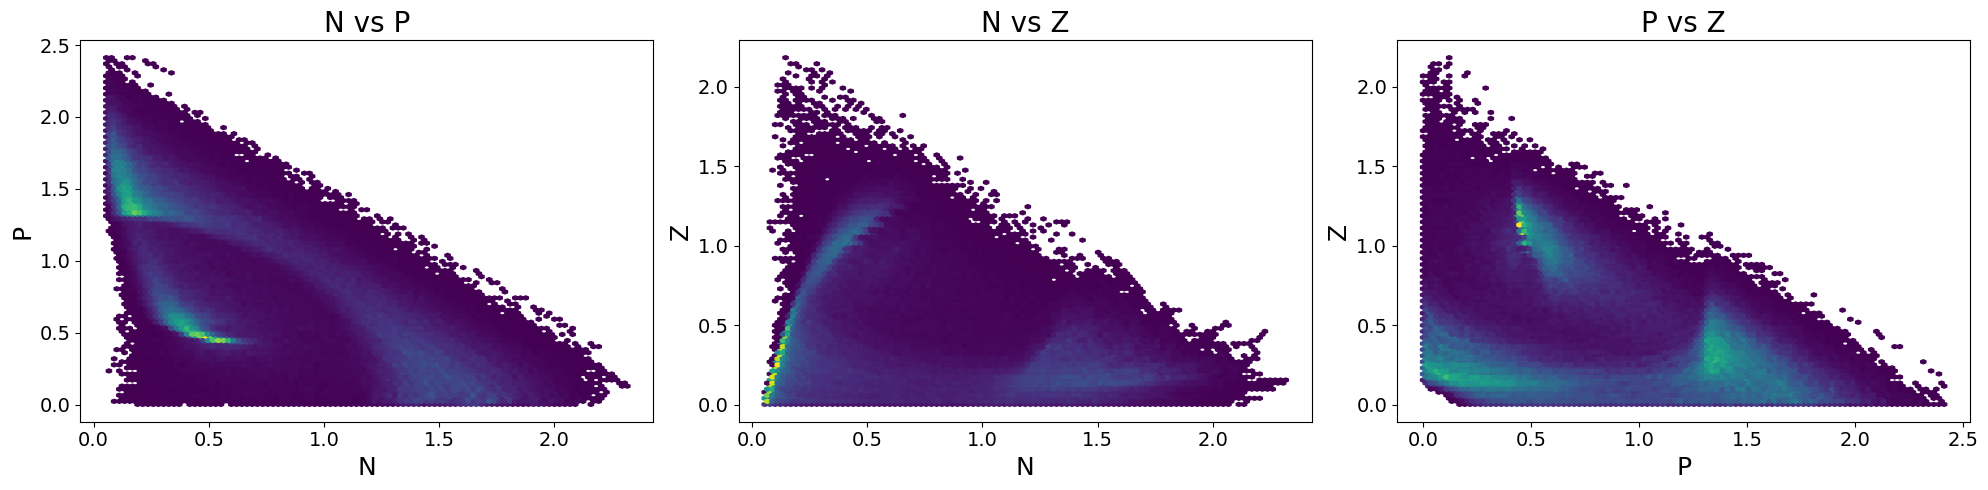

In [15]:
N = train_set[:,0]
P = train_set[:,1]
Z = train_set[:,2]

fig, axs = plt.subplots(1, 3, figsize=(20, 5))

font_title = 20
font_label = 18
font_tick = 14

# N vs P
axs[0].hexbin(N, P, gridsize=100, cmap='viridis', mincnt=1)
axs[0].set_xlabel("N", fontsize=font_label)
axs[0].set_ylabel("P", fontsize=font_label)
axs[0].set_title("N vs P", fontsize=font_title)
axs[0].tick_params(axis='both', labelsize=font_tick)

# N vs Z
axs[1].hexbin(N, Z, gridsize=100, cmap='viridis', mincnt=1)
axs[1].set_xlabel("N", fontsize=font_label)
axs[1].set_ylabel("Z", fontsize=font_label)
axs[1].set_title("N vs Z", fontsize=font_title)
axs[1].tick_params(axis='both', labelsize=font_tick)

# P vs Z
axs[2].hexbin(P, Z, gridsize=100, cmap='viridis', mincnt=1)
axs[2].set_xlabel("P", fontsize=font_label)
axs[2].set_ylabel("Z", fontsize=font_label)
axs[2].set_title("P vs Z", fontsize=font_title)
axs[2].tick_params(axis='both', labelsize=font_tick)

plt.tight_layout()
# plt.savefig("/Users/egank31/Documents/Documents - Otto/lab_meetings/figures/uniformN_dirPZ_initial_npz_hexbin_plots.png", dpi=300, bbox_inches='tight')
plt.show()


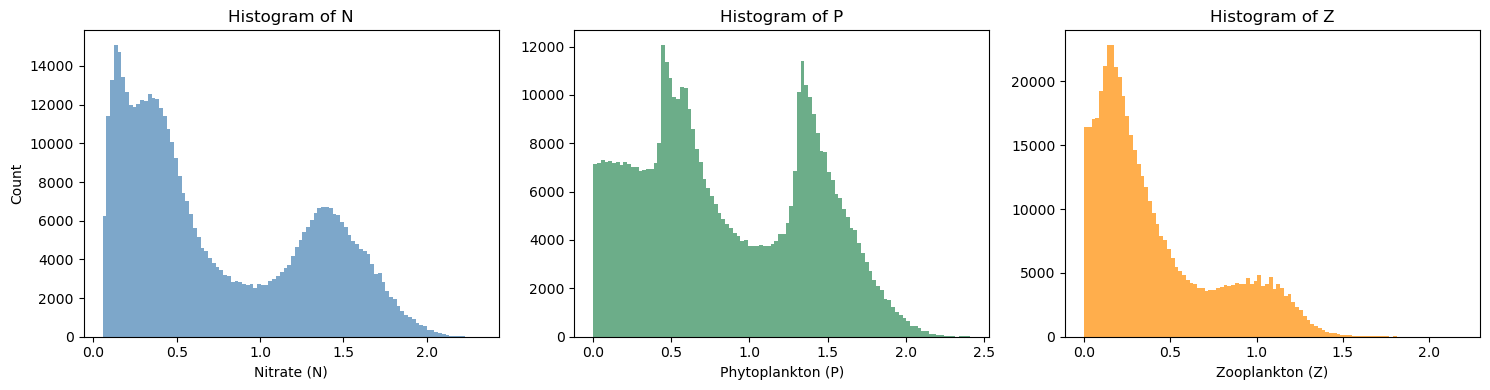

In [16]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.hist(N, bins=100, color="steelblue", alpha=0.7)
plt.xlabel("Nitrate (N)")
plt.ylabel("Count")
plt.title("Histogram of N")

plt.subplot(1,3,2)
plt.hist(P, bins=100, color="seagreen", alpha=0.7)
plt.xlabel("Phytoplankton (P)")
plt.title("Histogram of P")

plt.subplot(1,3,3)
plt.hist(Z, bins=100, color="darkorange", alpha=0.7)
plt.xlabel("Zooplankton (Z)")
plt.title("Histogram of Z")

plt.tight_layout()
plt.show()


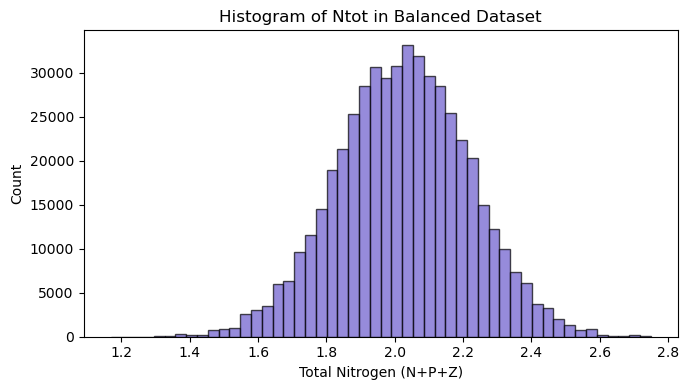

In [18]:
# Compute Ntot for each state
Ntot_vals = train_set.sum(axis=1)

# Plot histogram
plt.figure(figsize=(7,4))
plt.hist(Ntot_vals, bins=50, color="slateblue", alpha=0.7, edgecolor="black")
# plt.axvline(1.8, color="red", linestyle="--", label="1.8")
# plt.axvline(2.2, color="red", linestyle="--", label="2.2")
plt.xlabel("Total Nitrogen (N+P+Z)")
plt.ylabel("Count")
plt.title("Histogram of Ntot in Balanced Dataset")
plt.tight_layout()
plt.show()


In [19]:
Ntot_vals = train_set.sum(axis=1)  # total nitrogen per state

in_range = (Ntot_vals >= 1.8) & (Ntot_vals <= 2.2)
fraction_in_range = in_range.mean() * 100  # percentage

print(f"{fraction_in_range:.2f}% of states have Ntot in [1.8, 2.2]")


69.64% of states have Ntot in [1.8, 2.2]


In [20]:
minutes_per_step = 1
dt = minutes_per_step / (60*24)   # 1 minute in days
steps = 10                        # 10 minutes horizon
times = np.linspace(0, steps*dt, steps+1)  # 0, 1min, 2min, ..., 10min

array([0.        , 0.00069444, 0.00138889, 0.00208333, 0.00277778,
       0.00347222, 0.00416667, 0.00486111, 0.00555556, 0.00625   ,
       0.00694444])

In [21]:
def one_step_target(IC, phi):
    # Evolve from IC for 10 minutes with 1-min steps
    traj = rk4(npz_nl, IC, times, None, None, phi)
    x0 = traj[0]      # initial state
    x10 = traj[-1]    # state after 10 minutes
    return x0, x10


In [22]:
# Suppose ICs is your pool of current states
pairs = Parallel(n_jobs=-1)(
    delayed(one_step_target)(IC, phi) for IC in train_set
)

X0 = np.stack([p[0] for p in pairs])   # inputs
X10 = np.stack([p[1] for p in pairs])  # targets

print("Inputs:", X0.shape)
print("Targets:", X10.shape)


Inputs: (500000, 3)
Targets: (500000, 3)


In [23]:
import pandas as pd
# Step 2: save as CSV
df = pd.DataFrame(
    np.hstack([X0, X10]),
    columns=["N0", "P0", "Z0", "N10", "P10", "Z10"]
)

# near_val = int(near_fraction * 100)
# far_val = int(100 - near_val)
# df.to_csv(f"../data/npz_training_set.csv", index=False)
print("Saved dataset:", df.shape)



Saved dataset: (500000, 6)


In [27]:
# Create a DataFrame
df = pd.DataFrame(holdout_set, columns=["N", "P", "Z"])
# Save to CSV
# out_path = f"../data/npz_holdout_set.csv"
# df.to_csv(out_path, index=False)

# print(f"Saved holdout initial states to {out_path} with shape {df.shape}")


In [25]:
# Create a DataFrame
df = pd.DataFrame(test_set, columns=["N", "P", "Z"])
# Save to CSV
# out_path = f"../data/npz_test_set.csv"
# df.to_csv(out_path, index=False)

# print(f"Saved test initial states to {out_path} with shape {df.shape}")


In [26]:
# Create a DataFrame
df = pd.DataFrame(jacobian_set, columns=["N", "P", "Z"])
# Save to CSV
# out_path = f"../data/npz_jacobian_set.csv"
# df.to_csv(out_path, index=False)

# print(f"Saved jacobian initial states to {out_path} with shape {df.shape}")
